In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
# Dark Mode Plots
plt.style.use('dark_background')
import corner
import ast

In [86]:
# Make the corner plot for the MCMC results
system_name = 'J2017'
model_ver = 'sie'
mcmc_samples_path = f'../{system_name}/mcmc/{model_ver}_mcmc.dat'
samples = pd.read_csv(mcmc_samples_path, delim_whitespace=True, header=None, names=['chi2', 'vel_disp', 'x', 'y', 'ellip', 'pa' ])


In [87]:
samples

,chi2,vel_disp,x,y,ellip,pa
0,7.526569,150.7417,0.442231,-0.070652,0.461657,97.24517
1,7.662189,150.7815,0.441467,-0.071306,0.461631,97.16667
2,8.618882,150.8392,0.439981,-0.068020,0.464707,97.16193
3,11.055120,151.0948,0.436629,-0.068239,0.462758,97.16330
4,13.098920,150.8527,0.440561,-0.076775,0.462807,97.23909
...,...,...,...,...,...,...
2690,14.950600,149.9884,0.438485,-0.070683,0.468503,96.92144
2691,16.715540,150.7817,0.442032,-0.063167,0.464022,96.87340
2692,15.767620,151.2357,0.441489,-0.063189,0.472848,96.85523
2693,13.392480,150.7102,0.441533,-0.062187,0.480824,96.96487


In [88]:
masked_samples = samples.drop(columns=['chi2']).to_numpy()

In [89]:
# # Masked Samples with no accept column
# masked_samples = samples[samples['accept'] == 'accept'].copy()
# masked_samples = masked_samples.drop(columns=['accept', 'chi2']).to_numpy()
# masked_samples

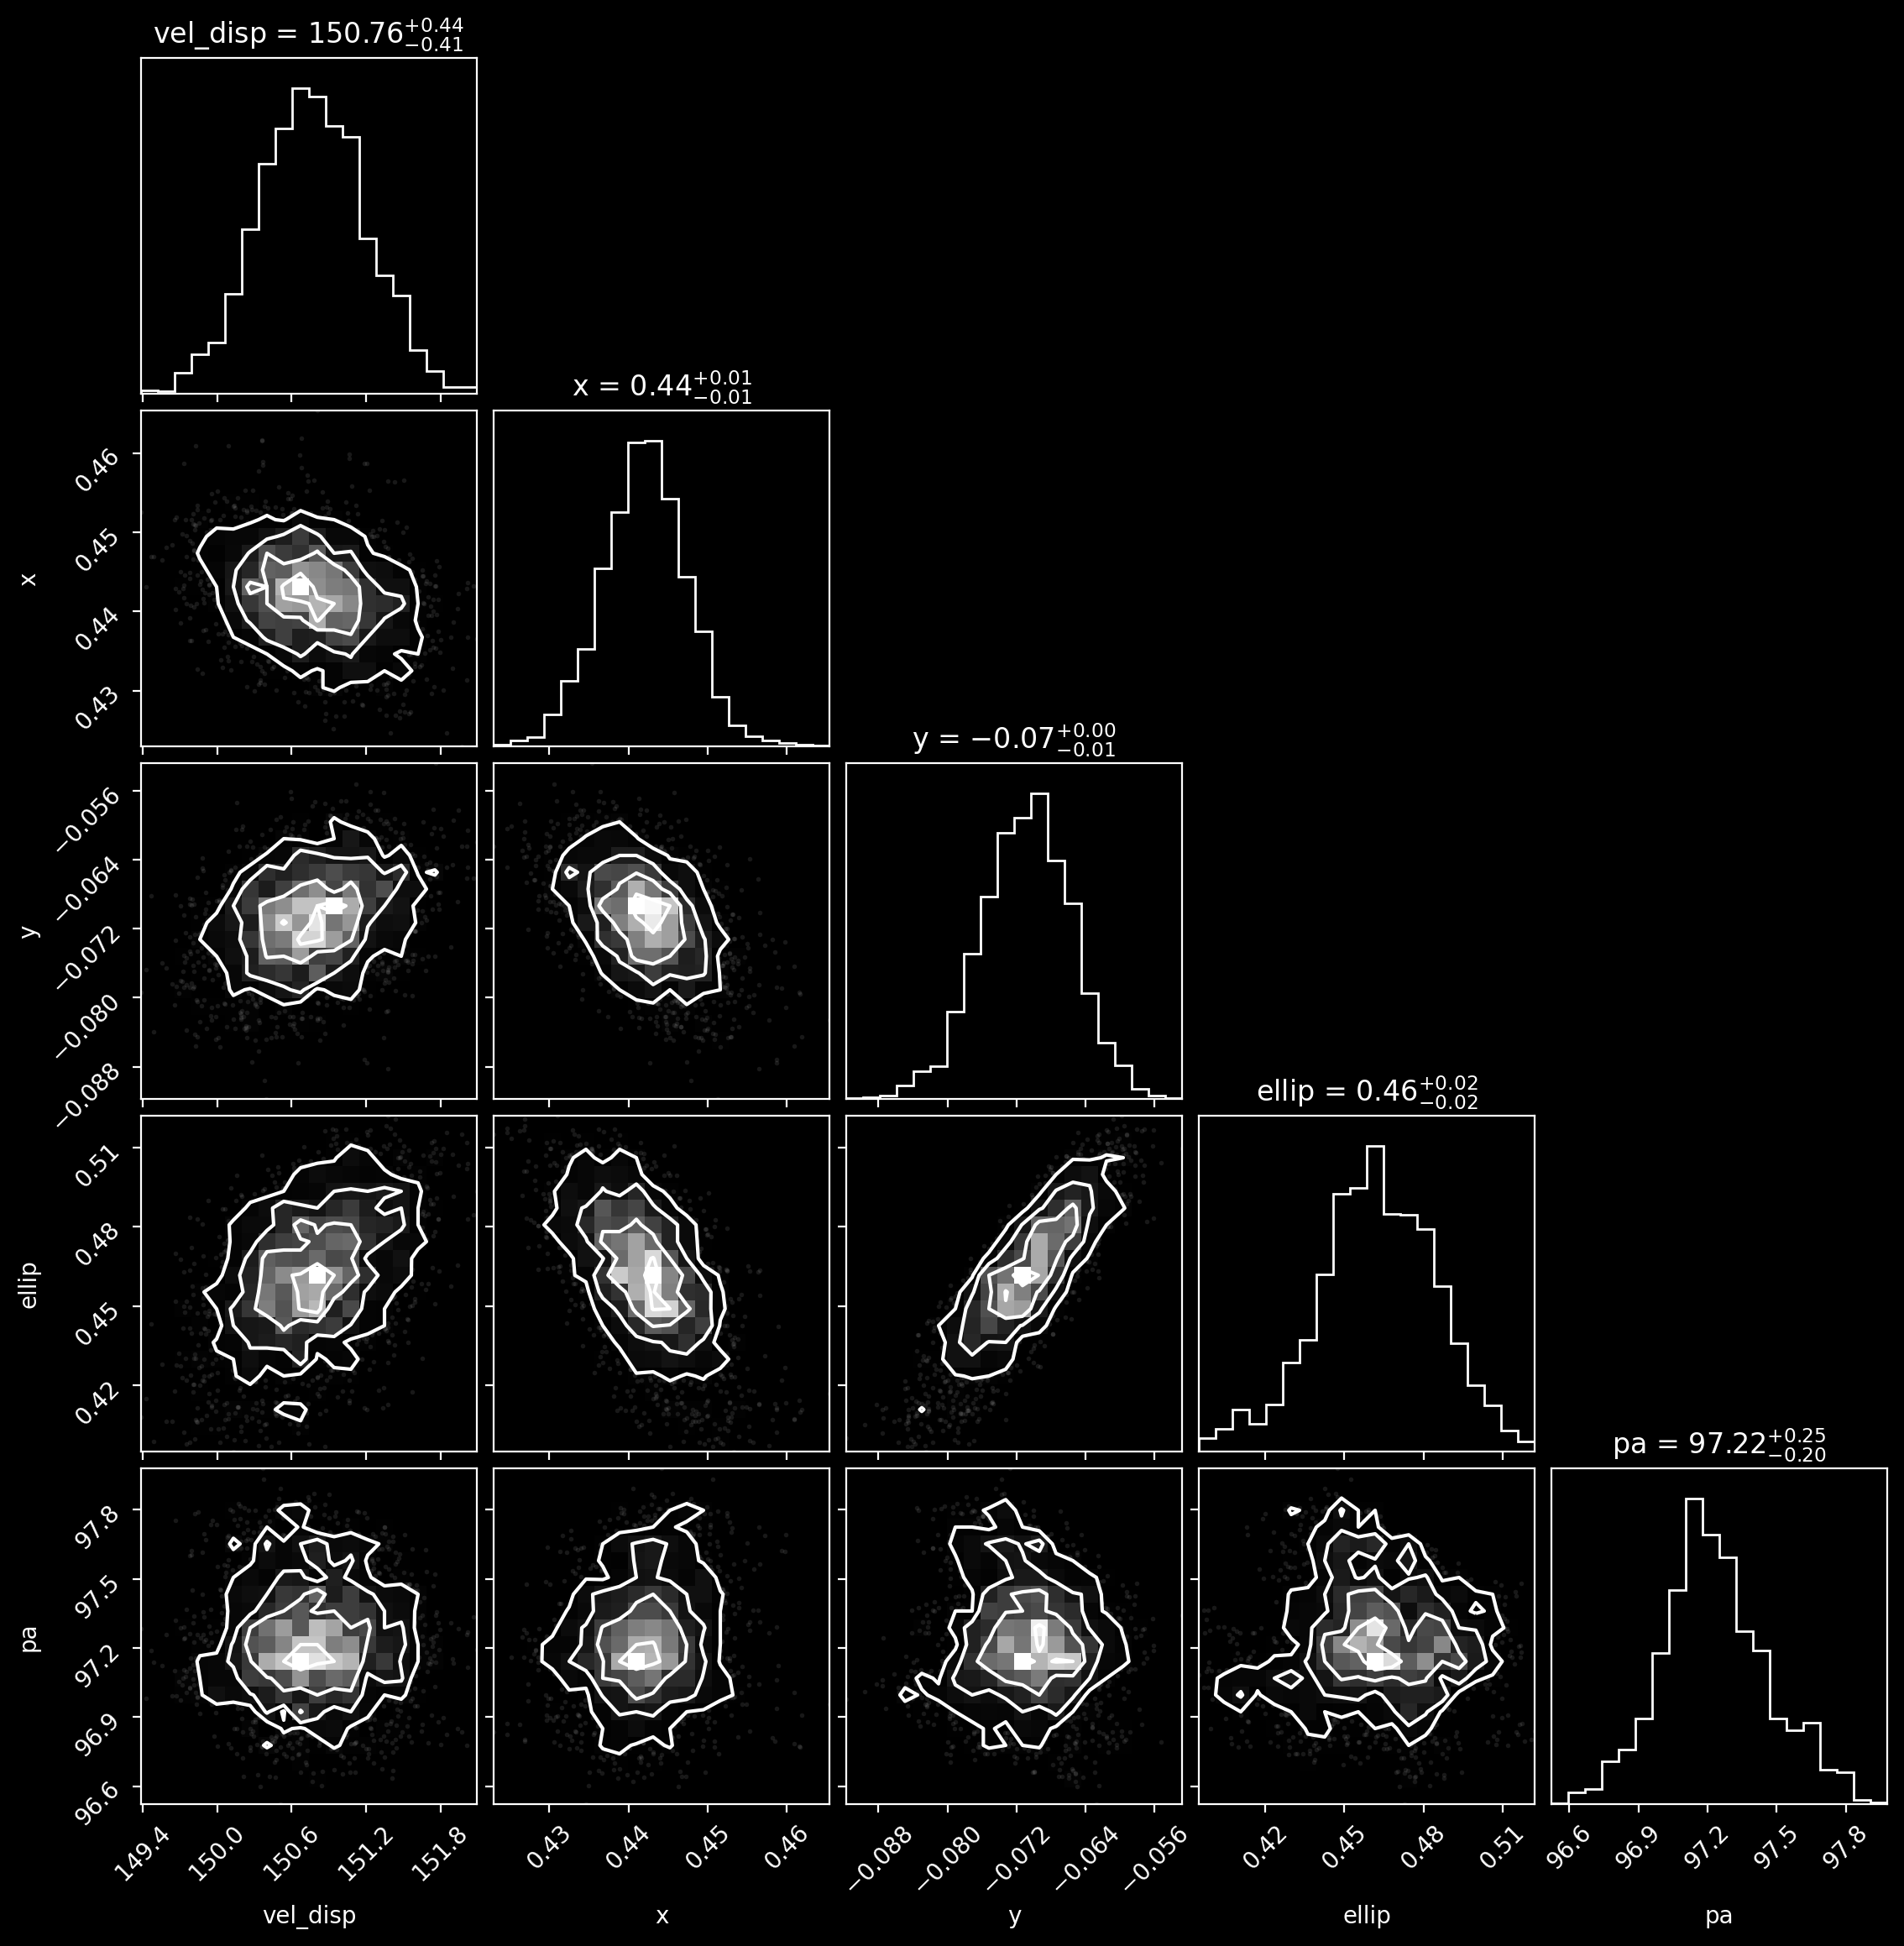

In [90]:
# Remove the first column when loading the samples, as it is the accepted/rejected column
labels = ['vel_disp', 'x', 'y', 'ellip', 'pa']
fig = corner.corner(masked_samples, labels=labels, show_titles=True)
plt.savefig(f'../{system_name}/mcmc/{model_ver}_corner.png')